In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [21]:
import pandas as pd

df = pd.read_csv("/kaggle/input/datasets/vaibhavjha26/indian-tech-jobs-2026/indian_tech_jobs_2026.csv")

df.head()

,job_id,job_title,company_name,company_rating,location,scraped_city,role_category,experience_raw,experience_min_yrs,experience_max_yrs,...,scraped_at,salary_tier,experience_tier,is_senior,primary_city,skill_domain,salary_midpoint_lpa,days_since_posted,is_fresher_friendly,salary_negotiable
0,1,Data Scientist,Cisco,4.1,Bengaluru,Bangalore,Data Scientist,7-10 Yrs,7.0,10.0,...,2025-06-10,Undisclosed,Senior (6-8 Yrs),False,Bangalore,Business Intelligence,0.0,21.0,False,False
1,2,Data Scientist,Caterpillar Inc,4.1,Bengaluru,Bangalore,Data Scientist,4-8 Yrs,4.0,8.0,...,2025-06-10,Undisclosed,Mid (3-5 Yrs),False,Bangalore,AI/ML/DL,0.0,21.0,False,False
2,3,Analytics Data Scientist,Foreign IT Consulting MNC,3.6,"Hyderabad, Chennai, Bengaluru",Bangalore,Data Scientist,4-9 Yrs,4.0,9.0,...,2025-06-10,Undisclosed,Mid (3-5 Yrs),False,Hyderabad,Business Intelligence,0.0,21.0,False,False
3,4,Data Scientist,Fortune 500 IT Services Company,3.6,"Mumbai, Bengaluru",Bangalore,Data Scientist,10-14 Yrs,0.0,0.0,...,2025-06-10,Undisclosed,Fresher,False,Mumbai,Data Science,0.0,21.0,True,False
4,5,Sr. Artificial Intelligence Engineer,Fortune 500 Product-based MNC,3.6,"Pune, Bengaluru",Bangalore,Data Scientist,5-10 Yrs,5.0,10.0,...,2025-06-10,Undisclosed,Mid (3-5 Yrs),True,Pune,Data Science,0.0,21.0,False,False


In [3]:
df.shape

(23201, 32)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23201 entries, 0 to 23200
Data columns (total 32 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   job_id               23201 non-null  int64  
 1   job_title            23201 non-null  object 
 2   company_name         23201 non-null  object 
 3   company_rating       23201 non-null  float64
 4   location             23201 non-null  object 
 5   scraped_city         23201 non-null  object 
 6   role_category        23201 non-null  object 
 7   experience_raw       23201 non-null  object 
 8   experience_min_yrs   23201 non-null  float64
 9   experience_max_yrs   23201 non-null  float64
 10  salary_raw           23201 non-null  object 
 11  salary_min_lpa       23201 non-null  float64
 12  salary_max_lpa       23201 non-null  float64
 13  salary_disclosed     23201 non-null  bool   
 14  skills_required      23201 non-null  object 
 15  skills_count         23201 non-null 

In [5]:
df.head()

,job_id,job_title,company_name,company_rating,location,scraped_city,role_category,experience_raw,experience_min_yrs,experience_max_yrs,...,scraped_at,salary_tier,experience_tier,is_senior,primary_city,skill_domain,salary_midpoint_lpa,days_since_posted,is_fresher_friendly,salary_negotiable
0,1,Data Scientist,Cisco,4.1,Bengaluru,Bangalore,Data Scientist,7-10 Yrs,7.0,10.0,...,2025-06-10,Undisclosed,Senior (6-8 Yrs),False,Bangalore,Business Intelligence,0.0,21.0,False,False
1,2,Data Scientist,Caterpillar Inc,4.1,Bengaluru,Bangalore,Data Scientist,4-8 Yrs,4.0,8.0,...,2025-06-10,Undisclosed,Mid (3-5 Yrs),False,Bangalore,AI/ML/DL,0.0,21.0,False,False
2,3,Analytics Data Scientist,Foreign IT Consulting MNC,3.6,"Hyderabad, Chennai, Bengaluru",Bangalore,Data Scientist,4-9 Yrs,4.0,9.0,...,2025-06-10,Undisclosed,Mid (3-5 Yrs),False,Hyderabad,Business Intelligence,0.0,21.0,False,False
3,4,Data Scientist,Fortune 500 IT Services Company,3.6,"Mumbai, Bengaluru",Bangalore,Data Scientist,10-14 Yrs,0.0,0.0,...,2025-06-10,Undisclosed,Fresher,False,Mumbai,Data Science,0.0,21.0,True,False
4,5,Sr. Artificial Intelligence Engineer,Fortune 500 Product-based MNC,3.6,"Pune, Bengaluru",Bangalore,Data Scientist,5-10 Yrs,5.0,10.0,...,2025-06-10,Undisclosed,Mid (3-5 Yrs),True,Pune,Data Science,0.0,21.0,False,False


In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df['primary_city'].value_counts().head(10)

primary_city
Mumbai       3276
Bangalore    2830
Chennai      2666
Pune         2606
Noida        2585
Gurgaon      2210
Remote       2010
Kolkata      1735
Ahmedabad    1352
Delhi         920
Name: count, dtype: int64

In [8]:
df['role_category'].value_counts().head(10)

role_category
Data Scientist               6455
Data Analyst                 4729
Business Analyst             4505
Machine Learning Engineer    4004
Data Engineer                1922
Python Developer             1586
Name: count, dtype: int64

In [9]:
df['is_fresher_friendly'].value_counts()

is_fresher_friendly
False    19019
True      4182
Name: count, dtype: int64

In [10]:
round(df['is_fresher_friendly'].mean()*100,2)

np.float64(18.03)

In [11]:
df['salary_midpoint_lpa'].describe()

count    23201.000000
mean         1.827872
std          6.109373
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max         87.500000
Name: salary_midpoint_lpa, dtype: float64

In [12]:
df[df['salary_midpoint_lpa'] > 0]['salary_midpoint_lpa'].describe()

count    2766.000000
mean       15.332050
std        10.298191
min         0.050000
25%         7.500000
50%        14.000000
75%        21.500000
max        87.500000
Name: salary_midpoint_lpa, dtype: float64

In [13]:
df.groupby('skill_domain')['salary_midpoint_lpa']\
  .mean()\
  .sort_values(ascending=False)

skill_domain
Cloud & DevOps           2.978485
AI/ML/DL                 2.172283
Data Engineering         1.978928
Data Science             1.814292
Business Intelligence    1.361584
Name: salary_midpoint_lpa, dtype: float64

In [14]:
df.groupby('primary_city')['salary_midpoint_lpa']\
  .mean()\
  .sort_values(ascending=False)\
  .head(10)

primary_city
Mumbai(Wadala East)         30.000000
Chennai(Pallavaram)         27.500000
North Goa                   26.250000
Chennai(Tamil Nagar)        26.250000
Chennai(Omr)                24.500000
Kolkata(Kolkata Dakshin)    22.500000
Pune(Mahalunge +2)          17.500000
Pune(Viman Nagar)           16.714286
Mumbai(Vikhroli)            16.540000
Chennai(Ambattur)           15.000000
Name: salary_midpoint_lpa, dtype: float64

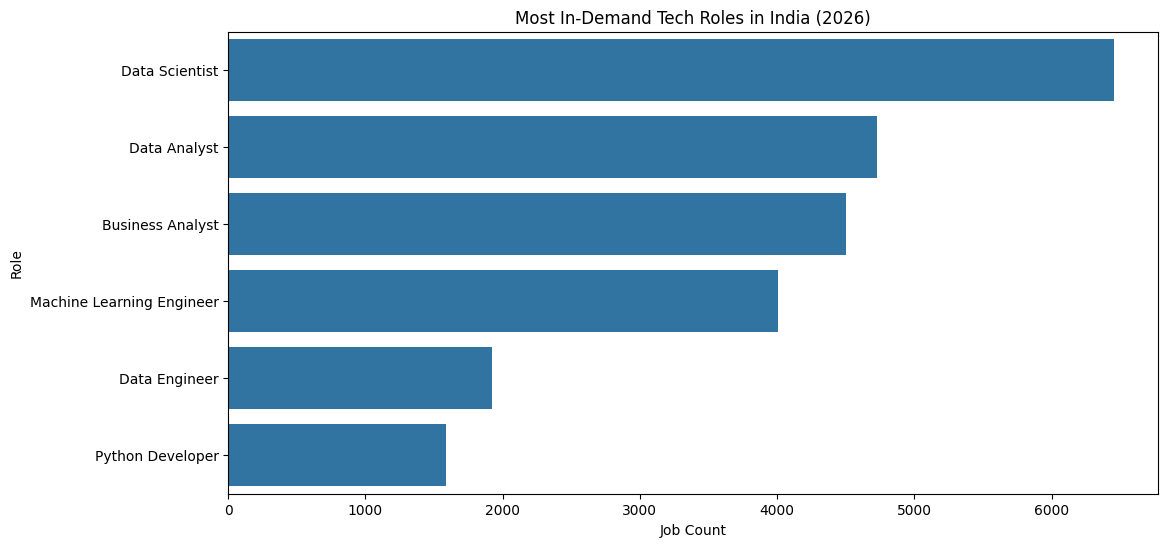

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

top_roles = df['role_category'].value_counts()

sns.barplot(
    x=top_roles.values,
    y=top_roles.index
)

plt.title("Most In-Demand Tech Roles in India (2026)")
plt.xlabel("Job Count")
plt.ylabel("Role")

plt.show()

In [25]:
salary_df = df[df['salary_midpoint_lpa'] > 0]

In [24]:
salary_df.groupby('skill_domain')['salary_midpoint_lpa']\
         .mean()\
         .sort_values(ascending=False)

skill_domain
Cloud & DevOps           19.023351
AI/ML/DL                 18.262143
Data Engineering         17.154293
Data Science             13.758382
Business Intelligence    12.344140
Name: salary_midpoint_lpa, dtype: float64

In [26]:
salary_df.groupby('primary_city')['salary_midpoint_lpa']\
         .mean()\
         .sort_values(ascending=False)\
         .head(10)

primary_city
Mumbai(Prabhadevi)          36.25
Mumbai(Wadala East)         30.00
Pune(Viman Nagar)           29.25
Chennai(Pallavaram)         27.50
Chennai(Tamil Nagar)        26.25
North Goa                   26.25
Mumbai(Vikhroli)            24.81
Chennai(Omr)                24.50
Kolkata(Kolkata Dakshin)    22.50
Chennai(Sholinganallur)     21.75
Name: salary_midpoint_lpa, dtype: float64

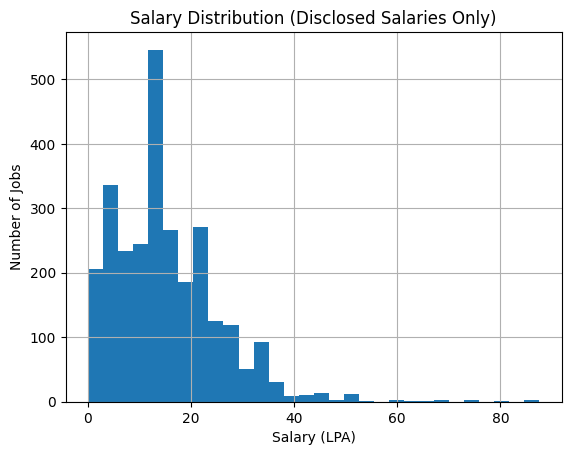

In [27]:
import matplotlib.pyplot as plt

salary_df['salary_midpoint_lpa'].hist(bins=30)

plt.title('Salary Distribution (Disclosed Salaries Only)')
plt.xlabel('Salary (LPA)')
plt.ylabel('Number of Jobs')

plt.show()

In [28]:
df['experience_tier'].value_counts()

experience_tier
Mid (3-5 Yrs)              10112
Junior (0-2 Yrs)            4915
Senior (6-8 Yrs)            4810
Fresher                     2219
Lead/Architect (9+ Yrs)     1145
Name: count, dtype: int64

In [29]:
df['experience_min_yrs'].mean()

np.float64(4.135080384466187)

In [30]:
df['experience_max_yrs'].mean()

np.float64(7.829059092280505)

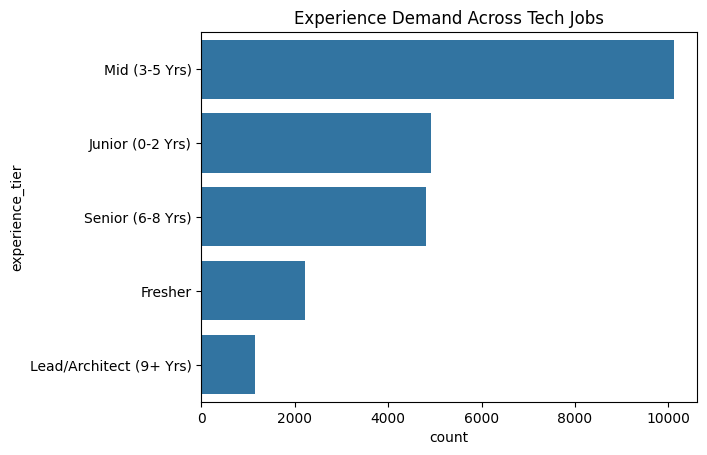

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(
    data=df,
    y='experience_tier',
    order=df['experience_tier'].value_counts().index
)

plt.title('Experience Demand Across Tech Jobs')
plt.show()

In [32]:
df['company_name'].value_counts().head(15)

company_name
Tata Consultancy Services    653
Accenture                    438
EY                           340
Leading Client               243
Infosys                      209
Capgemini                    195
Photon                       193
Logic Planet                 185
Hexaware Technologies        147
Sparix Global                126
Paytm                        111
Fractal Analytics            108
Krazy Mantra It              102
Han Digital Solution          98
Crisil                        98
Name: count, dtype: int64

In [33]:
df.groupby('company_name')['company_rating']\
  .mean()\
  .sort_values(ascending=False)\
  .head(15)

company_name
Asky Services Llp                          5.0
Inaaya Daycare & Activity Centre           5.0
Plan Optimus                               5.0
Plus Fitness 24 7 India                    5.0
VED Infomedia                              5.0
Worqhat                                    5.0
Infozion Technologies                      5.0
Cloven Media                               5.0
Astron Zircon                              5.0
Armory Gurugram                            5.0
Sparix Global                              5.0
Squapl Digital Media Technologies (opc)    5.0
Wpweb Infotech                             5.0
Intigniz Solutions                         5.0
AK Dezigns                                 5.0
Name: company_rating, dtype: float64

In [34]:
df['work_mode'].value_counts()

work_mode
On-site    18701
Hybrid      2347
Remote      2153
Name: count, dtype: int64